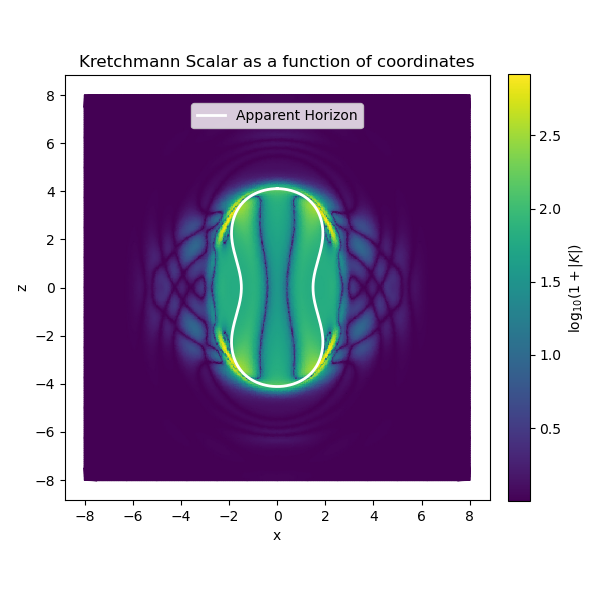

In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
# =========================
# 1. LOAD CSV
# =========================
data = np.loadtxt("/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.113_4.113/brill_twist_zsymmetric_4.113_4.113_200_100_2_2d/output_2d/xz/ana.CSI/prv.csv", delimiter=",", skiprows=1)

x = data[:, 2]   # Points:0
z = data[:, 4]   # Points:2
csi = data[:, 0] # ana.CSI

# =========================
# 2. LOG SCALING
# =========================
csi_plot = np.log10(1 + np.abs(csi))

# =========================
# 3. PLOT FIELD
# =========================
plt.figure(figsize=(6,6))

# Use tricontourf (works for unstructured points)
cf = plt.tripcolor(x, z, csi_plot, shading='gouraud', cmap='viridis')

# =========================
# 4. HORIZON
# =========================
horizon = np.loadtxt("/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.113_hdwg_108000.bin.txt", skiprows=1)
plt.plot(horizon[:,0], horizon[:,1], color='white', linewidth=2,label="Apparent Horizon")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95))
# =========================
# 5. AXES
# =========================
plt.xlabel("x")
plt.ylabel("z")
plt.gca().set_aspect('equal')

# Center axes (optional)
# =========================
# 5. AXES (NORMAL, SQUARE)
# =========================
ax = plt.gca()

# Remove centered axes (your current lines → DELETE them)
# ax.spines['left'].set_position('zero')
# ax.spines['bottom'].set_position('zero')

# Keep normal box
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

plt.xlabel("x")
plt.ylabel("z")

# Equal aspect (square)
ax.set_aspect('equal', adjustable='box')

# =========================
# 6. COLORBAR
# =========================
# =========================
# 6. COLORBAR (MATCH HEIGHT)
# =========================
# =========================
# 6. COLORBAR (CORRECT)
# =========================
fig = plt.gcf()
ax = plt.gca()

cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}(1 + |K|)$')

# =========================
# 7. SAVE
# =========================
plt.tight_layout()
plt.title("Kretchmann Scalar as a function of coordinates")
plt.savefig("figure.pdf", dpi=600)

plt.show()



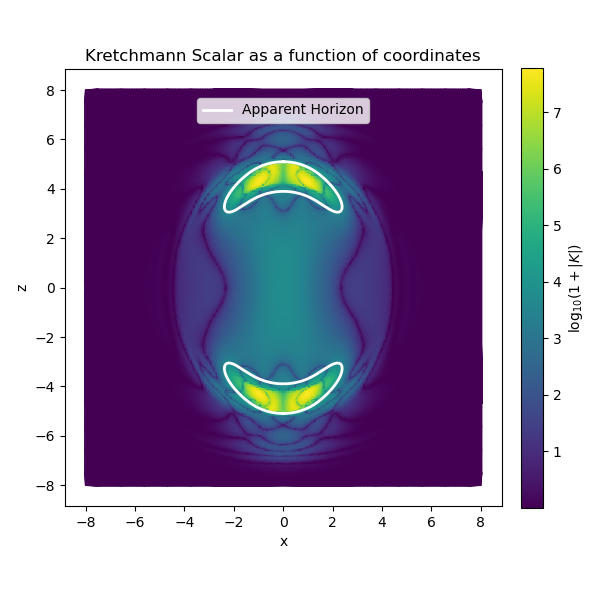

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
# =========================
# 1. LOAD CSV
# =========================
data = np.loadtxt("/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.114_4.114/brill_twist_zsymmetric_4.114_4.114_200_100_2d_original/output_2d/xz/ana.CSI/prv.csv", delimiter=",", skiprows=1)

x = data[:, 2]   # Points:0
z = data[:, 4]   # Points:2
csi = data[:, 0] # ana.CSI

# =========================
# 2. LOG SCALING
# =========================
csi_plot = np.log10(1 + np.abs(csi))

# =========================
# 3. PLOT FIELD
# =========================
plt.figure(figsize=(6,6))

# Use tricontourf (works for unstructured points)
cf = plt.tripcolor(x, z, csi_plot, shading='gouraud', cmap='viridis')

# =========================
# 4. HORIZON
# =========================
horizon = np.loadtxt("/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.114_bif.txt", skiprows=1)
plt.plot(horizon[:,0], horizon[:,1], color='white', linewidth=2,label="Apparent Horizon")
plt.plot(horizon[:,0], -horizon[:,1], color='white', linewidth=2,label="_nolegend_")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95))
# =========================
# 5. AXES
# =========================
plt.xlabel("x")
plt.ylabel("z")
plt.gca().set_aspect('equal')

# Center axes (optional)
# =========================
# 5. AXES (NORMAL, SQUARE)
# =========================
ax = plt.gca()

# Remove centered axes (your current lines → DELETE them)
# ax.spines['left'].set_position('zero')
# ax.spines['bottom'].set_position('zero')

# Keep normal box
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

plt.xlabel("x")
plt.ylabel("z")

# Equal aspect (square)
ax.set_aspect('equal', adjustable='box')

# =========================
# 6. COLORBAR
# =========================
# =========================
# 6. COLORBAR (MATCH HEIGHT)
# =========================
# =========================
# 6. COLORBAR (CORRECT)
# =========================
fig = plt.gcf()
ax = plt.gca()

cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}(1 + |K|)$')

# =========================
# 7. SAVE
# =========================
plt.tight_layout()
plt.title("Kretchmann Scalar as a function of coordinates")
plt.savefig("figure_4.114.pdf", dpi=600)

plt.show()



In [31]:
import numpy as np
import plotly.graph_objects as go

fig = go.Figure()

data = np.loadtxt("/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.114_4.114/brill_twist_zsymmetric_4.114_4.114_200_100_2d_original/output_2d/xz/ana.CSI/prv.csv", delimiter=",", skiprows=1)
horizon = np.loadtxt("/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.114_bif.txt", skiprows=1)

bifurcated = False

# --- Horizon data ---
x = horizon[:,0]
z = horizon[:,1]
zorg= 4.45
# --- Build closed loop ---
x_m = -x[1:-1]
z_m =  z[1:-1]

x_upper = np.concatenate([x, x_m[::-1]])
z_upper = np.concatenate([z, z_m[::-1]])

x_upper = np.append(x_upper, x_upper[0])
z_upper = np.append(z_upper, z_upper[0])

# --- Plot horizon ---
fig.add_trace(go.Scatter(
    x=x_upper,
    y=z_upper,
    mode="lines",
    showlegend=False,
    line=dict(width=3, color="blue")
))

# --- Lower loop if bifurcated ---
if bifurcated:
    fig.add_trace(go.Scatter(
        x=x_upper,
        y=-z_upper,
        mode="lines",
        showlegend=False,
        line=dict(width=3, color="blue")
    ))

# --- Initial ray ---
theta_vals = np.linspace(-0.77, -0.38, 80)

x_line = np.linspace(0, 3, 200)
z_line = np.tan(theta_vals[0]) * x_line + zorg

fig.add_trace(go.Scatter(
    x=x_line,
    y=z_line,
    mode="lines",
    line=dict(color="red", width=3),
    name="Ray"
))

# ✅ IMPORTANT: define AFTER adding ray
ray_trace_index = len(fig.data) - 1

# --- Frames ---
frames = []

for th in theta_vals:
    x_line = np.linspace(0, 3, 200)
    z_line = np.tan(th) * x_line +zorg

    frames.append(go.Frame(
        data=[go.Scatter(x=x_line, y=z_line)],
        traces=[ray_trace_index],   # ← correct now
        name=f"{th:.3f}"
    ))

fig.frames = frames

# --- Slider ---
fig.update_layout(
    sliders=[{
        "steps": [
            {
                "args": [[f"{th:.3f}"],
                         {"frame": {"duration": 0, "redraw": True},
                          "mode": "immediate"}],
                "label": f"{th:.2f}",
                "method": "animate"
            }
            for th in theta_vals
        ],
        "currentvalue": {"prefix": "θ = "}
    }]
)

# --- Layout ---
fig.update_layout(
    title="Horizon + Ray Test (Star-shaped check)",
    template='plotly_white',
    width=1000,
    height=1000,
    dragmode="pan",
    xaxis=dict(scaleanchor="y", scaleratio=1, title="x"),
    yaxis=dict(scaleratio=1, title="z"),
    font=dict(
        family="Garamond, Georgia, serif",
        size=20,
        color="black"
    )
)

fig.show()

NameError: name 'np' is not defined

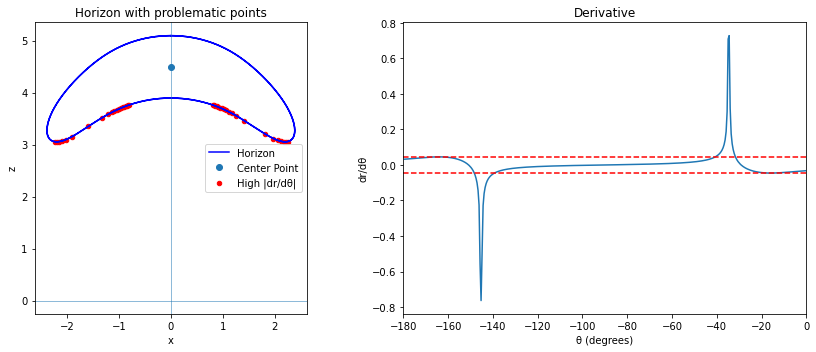

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load horizon
# =========================
horizon = np.loadtxt(
    "/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.114_bif.txt",
    skiprows=1
)

x = horizon[:,0]
z = horizon[:,1]

# =========================
# Build closed curve
# =========================
x_m = -x[1:-1]
z_m =  z[1:-1]

x_curve = np.concatenate([x, x_m[::-1]])
z_curve = np.concatenate([z, z_m[::-1]])

# =========================
# Choose center
# =========================
x_c = 0.0
z_c = 4.45

# =========================
# Compute r, theta
# =========================
dx = x_curve - x_c
dz = z_curve - z_c

r = np.sqrt(dx**2 + dz**2)
theta = np.arctan2(dz, dx)

# =========================
# Bin theta
# =========================
bins = np.linspace(-np.pi,np.pi, 800)
digitized = np.digitize(theta, bins)

theta_binned = []
r_binned = []
x_binned = []
z_binned = []

for i in range(1, len(bins)):
    mask = digitized == i
    if np.any(mask):
        # take point with max r (outer surface)
        idx = np.argmax(r[mask])
        theta_binned.append(theta[mask][idx])
        r_binned.append(r[mask][idx])
        x_binned.append(x_curve[mask][idx])
        z_binned.append(z_curve[mask][idx])

theta_binned = np.array(theta_binned)
r_binned = np.array(r_binned)
x_binned = np.array(x_binned)
z_binned = np.array(z_binned)

# =========================
# Sort
# =========================
idx = np.argsort(theta_binned)
theta_binned = theta_binned[idx]
r_binned = r_binned[idx]
x_binned = x_binned[idx]
z_binned = z_binned[idx]

# =========================
# Derivative
# =========================
theta_deg = np.degrees(theta_binned)
dr_dtheta = np.gradient(r_binned, theta_deg)

# =========================
# Find problematic points
# =========================
threshold = np.percentile(np.abs(dr_dtheta), 95)  # top 5%
bad = np.abs(dr_dtheta) > threshold

# =========================
# Plot
# =========================
plt.figure(figsize=(12,5))

# --- Horizon plot ---
plt.subplot(1,2,1)
plt.plot(x_curve, z_curve, 'b', label="Horizon")

# highlight problematic points
plt.scatter(x_binned[bad], z_binned[bad],
            color='red', s=20, label="High |dr/dθ|")

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("z")
plt.title("Horizon with problematic points")
plt.plot(0, 4.5, 'o',label="Center Point")

plt.legend()
  # 'o' creates a dot
# --- Derivative plot ---
plt.subplot(1,2,2)
plt.plot(theta_deg, dr_dtheta)
plt.axhline(threshold, color='r', linestyle='--')
plt.axhline(-threshold, color='r', linestyle='--')
plt.xlim(-180,0)
plt.xlabel("θ (degrees)")
plt.ylabel("dr/dθ")
plt.title("Derivative")
plt.savefig("problematic.pdf")
plt.tight_layout()
plt.show()

In [3]:
# =========================
# Convert to degrees
# =========================
theta_deg = np.degrees(theta_unique)

# =========================
# Plot
# =========================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(theta_deg, r_unique, '.')
plt.title("r(θ)")
plt.xlabel("θ (degrees)")
plt.ylabel("r")

plt.subplot(1,2,2)
plt.plot(theta_deg, dr_dtheta, '.')
plt.title("dr/dθ")
plt.xlabel("θ (degrees)")
plt.ylabel("dr/dθ")

plt.tight_layout()
plt.show()

NameError: name 'theta_unique' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# =========================
# Load data
# =========================
horizon = np.loadtxt(
    "/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.114_bif.txt",
    skiprows=1
)

bifurcated = True

x = horizon[:, 0]
z = horizon[:, 1]

# =========================
# Build closed curve
# =========================
x_m = -x[1:-1]
z_m =  z[1:-1]

x_upper = np.concatenate([x, x_m[::-1]])
z_upper = np.concatenate([z, z_m[::-1]])

x_upper = np.append(x_upper, x_upper[0])
z_upper = np.append(z_upper, z_upper[0])

# =========================
# Interactive function
# =========================
def plot_ray(theta, zc):

    plt.figure(figsize=(6,6))

    # Horizon
    plt.plot(x_upper, z_upper, 'b')

    if bifurcated:
        plt.plot(x_upper, -z_upper, 'b')

    # Ray
    r = np.linspace(0, 4, 300)
    x_line = r * np.sin(theta)
    z_line = zc + r * np.cos(theta)

    plt.plot(x_line, z_line, 'r')

    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)

    plt.gca().set_aspect('equal')
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)

    plt.title(f"θ = {theta:.2f}, z₀ = {zc:.2f}")
    plt.xlabel("x")
    plt.ylabel("z")

    plt.show()

# =========================
# Sliders
# =========================
interact(
    plot_ray,
    theta=FloatSlider(min=0.01, max=np.pi/2-0.01, step=0.02, value=0.3),
    zc=FloatSlider(min=np.min(z_upper), max=np.max(z_upper), step=0.05, value=0.0)
)

interactive(children=(FloatSlider(value=0.3, description='theta', max=1.5607963267948965, min=0.01, step=0.02)…

<function __main__.plot_ray(theta, zc)>

In [8]:
import numpy as np
import plotly.graph_objects as go

# ===== Load data from file =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"   # <-- put your file name here
data = np.loadtxt(filename)

# ===== Extract columns =====
proper_time = data[:, 0]
kretschmann = data[:, 1]

# ===== Compute log(abs(K)) =====
log_k = np.log(np.abs(kretschmann) + 1e-15)  # avoid log(0)
slow_time= -np.log(7.9-proper_time)

# ===== Plot =====
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=proper_time,
    y=log_k,
    mode='lines+markers',
    name='log|Kretschmann|'
))

fig.update_layout(
    title=f"log(|Kretschmann|) vs Proper Time ({filename})",
    xaxis_title="Proper Time",
    yaxis_title="log(|Kretschmann|)",
)

fig.show()

/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:14: RuntimeWarning:

invalid value encountered in log



In [59]:
import numpy as np
import plotly.graph_objects as go

# ===== Load data from file =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"   # <-- put your file name here
data = np.loadtxt(filename)

# ===== Extract columns =====
proper_time = data[:, 0]
kretschmann = data[:, 1]

# ===== Compute log(abs(K)) =====
log_k = np.log(np.abs(kretschmann) + 1e-15)  # avoid log(0)


# ===== Plot =====
fig = go.Figure()
slow_time= -np.log(10.2-proper_time)
fig.add_trace(go.Scatter(
    x=slow_time,
    y=log_k,
    mode='lines+markers',
    name='log|Kretschmann|'
))

fig.update_layout(
    title=f"log(|Kretschmann|) vs Proper Time ({filename})",
    xaxis_title="Proper Time",
    yaxis_title="log(|Kretschmann|)",
)

fig.show()

/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:18: RuntimeWarning:

invalid value encountered in log



In [6]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

# Force clean rendering (avoids duplicate plots)
pio.renderers.default = "browser"

# ===== Load data =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"
data = np.loadtxt(filename)

proper_time = data[:, 0]
kretschmann = data[:, 1]

# log(|K|)
log_k = np.log(np.abs(kretschmann) + 1e-15)

# ===== t* range =====
t_star_values = np.arange(7,13, 0.5)

# ===== Precompute ONLY physical branch (τ < t*) =====
slow_time_all = []
log_k_all = []

for t in t_star_values:
    mask = proper_time < t   # 👈 CRUCIAL FIX
    
    tau_valid = proper_time[mask]
    k_valid = log_k[mask]
    
    slow_time = -np.log(t - tau_valid)
    
    slow_time_all.append(slow_time)
    log_k_all.append(k_valid)

# ===== Create figure =====
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=slow_time_all[0],
    y=log_k_all[0],
    mode='lines',
    name='log|K|'
))

# ===== Slider =====
steps = []
for i, t in enumerate(t_star_values):
    steps.append(dict(
        method="restyle",
        args=[{
            "x": [slow_time_all[i]],
            "y": [log_k_all[i]]
        }, [0]],
        label=f"{t:.1f}"
    ))

fig.update_layout(
    sliders=[dict(
        active=0,
        currentvalue={"prefix": "t*: "},
        steps=steps
    )],
    title="log(|Kretschmann|) vs Slow Time",
    xaxis_title="Slow time = -log(t* - τ)",
    yaxis_title="log(|Kretschmann|)"
)

print("Number of traces:", len(fig.data))  # should be 1

fig.show()

Number of traces: 1
